<a href="https://colab.research.google.com/github/raditya12/PCVK_Ganjil2026/blob/master/Week7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ===== SEL IDENTITAS - JANGAN DIHAPUS, HARUS SEL PERTAMA =====
import sys, platform, hashlib, datetime, zoneinfo
NAMA = 'Raditya Riefki'
NIM = '244107020204'
N = int(NIM[-3:])
PARAM = {
    'kernel_kecil': 3,
    'kernel_besar': 5,
    'kernel_gaussian': 21,
    'sigma': round(2.0 + (N % 5) * 0.5, 1),
    'salt_pepper': round(0.02 + (N % 4) * 0.01, 2),
    'bilateral_d': 9,
    'bilateral_sigma': 75,
}
waktu = datetime.datetime.now(zoneinfo.ZoneInfo('Asia/Jakarta'))
print('NAMA  :', NAMA)
print('NIM   :', NIM, '| N =', N)
for k, v in PARAM.items():
    print('%-16s :' % k, v)
print('WAKTU :', waktu.strftime('%Y-%m-%d %H:%M:%S %Z'))
print('SISTEM:', sys.version.split()[0], platform.platform())
kunci = NIM + '|' + waktu.strftime('%Y-%m-%d')
print('TOKEN :', hashlib.sha256(kunci.encode()).hexdigest()[:16])

NAMA  : Raditya Riefki
NIM   : 244107020204 | N = 204
kernel_kecil     : 3
kernel_besar     : 5
kernel_gaussian  : 21
sigma            : 4.0
salt_pepper      : 0.02
bilateral_d      : 9
bilateral_sigma  : 75
WAKTU : 2026-10-06 18:24:40 WIB
SISTEM: 3.13.16 Linux-6.6.122+-x86_64-with-glibc2.39
TOKEN : 9e8f00acbb90c7a2


# Modul 6 — Filter Spasial (Low Pass, High Pass, Point/Line/Edge Detection)

**Nama:** Raditya Riefki · **NIM:** 244107020204 · **Absen:** 19

Notebook ini mengerjakan **Bagian D. Praktikum Filter** dan **Tugas Praktikum** pada Modul 6. Fungsi konvolusi dibuat manual (tanpa `cv.filter2D`) lalu dipakai untuk Average, Low Pass, High Pass, Sharpen, Emboss, dan Sobel. Filter pustaka (Canny, Gaussian 21×21, Bilateral) dipakai sesuai instruksi modul. Semua citra dibaca dari folder `Images/`.

## D.0 — Persiapan

Membaca citra dari folder `Images/`, menyiapkan fungsi bantu tampilan, dan menyiapkan fungsi konvolusi. Notebook dapat dijalankan di Colab (folder `Images` pada Drive) maupun lokal (folder `Images` di direktori notebook).

In [2]:
%matplotlib inline
from pathlib import Path
import math
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from numpy.lib.stride_tricks import sliding_window_view

try:
    from google.colab import drive
except ImportError:
    DI_COLAB = False
else:
    DI_COLAB = True
    drive.mount('/content/drive')

IMAGE_DIR = Path('/content/drive/MyDrive/Images')
plt.rcParams.update({'figure.dpi': 100, 'axes.titlesize': 10})

def baca(path_or_name):
    raw = str(path_or_name)
    nama = Path(raw).name
    lokal_images = Path.cwd() / 'Images' / nama
    if raw.startswith('/'):
        kandidat = [raw, str(lokal_images), nama]
    else:
        kandidat = [str(IMAGE_DIR / raw), str(lokal_images), raw]
    for p in kandidat:
        img = cv.imread(p, cv.IMREAD_COLOR)
        if img is not None:
            return img
    raise FileNotFoundError(f'Citra gagal dibaca. Dicoba: {kandidat}')

def ke_abu(img):
    return cv.cvtColor(img, cv.COLOR_BGR2GRAY) if img.ndim == 3 else img.copy()

def tampil(ax, img, judul):
    if img.ndim == 2:
        ax.imshow(img, cmap='gray', vmin=0, vmax=255, interpolation='nearest')
    else:
        ax.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB), interpolation='nearest')
    ax.set_title(NIM + ' - ' + judul, fontsize=9)
    ax.axis('off')

def deret(citra, judul, ncols=None, skala=3.2):
    n = len(citra)
    ncols = ncols or n
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(skala * ncols, skala * nrows), squeeze=False)
    for ax in axes.flat:
        ax.axis('off')
    for ax, img, t in zip(axes.flat, citra, judul):
        tampil(ax, img, t)
    plt.tight_layout()
    plt.show()

def tabel(kolom, baris):
    teks = '| ' + ' | '.join(kolom) + ' |\n'
    teks += '| ' + ' | '.join(['---'] * len(kolom)) + ' |\n'
    teks += '\n'.join('| ' + ' | '.join(map(str, row)) + ' |' for row in baris)
    display(Markdown(teks))

lena = ke_abu(baca('/content/drive/MyDrive/Images/lena.jpg'))
print('lena grayscale :', lena.shape)
print('IMAGE_DIR      :', IMAGE_DIR)

Mounted at /content/drive
lena grayscale : (512, 512)
IMAGE_DIR      : /content/drive/MyDrive/Images


## D.1 — Fungsi konvolusi manual

Konvolusi adalah penjumlahan perkalian setiap titik kernel dengan piksel tetangga citra. Implementasi mengikuti pseudocode modul:

```text
for x = 0 .. lebar-1
  for y = 0 .. tinggi-1
    z(x,y) = 0
    for k1 = 0 .. lebar_kernel-1
      for k2 = 0 .. tinggi_kernel-1
        z(x,y) = z(x,y) + H(k1,k2) * Img(x+k1, y+k2)
```

Masalah piksel pinggir ("menggantung") diselesaikan dengan tiga pendekatan: `zero` (tepi dianggap 0), `replicate` (duplikasi elemen tepi), dan `none` (piksel pinggir tidak dikonvolusi sehingga nilainya tetap). Karena loop Python lambat, disediakan `konvolusi_vektor` berbasis NumPy dengan matematika yang sama; keduanya diverifikasi identik, dan hasil vektor juga dicek terhadap `cv.filter2D` (hanya sebagai pembanding, bukan mesin konvolusi utama).

> **Catatan:** pseudocode modul menghitung `H(k1,k2) * Img(x+k1, y+k2)` tanpa membalik kernel, sehingga secara matematis ini **korelasi silang**, bukan konvolusi dengan pembalikan kernel. Implementasi mengikuti pseudocode tersebut. Untuk kernel simetris (Average, Gaussian, High Pass, Sharpen) korelasi dan konvolusi menghasilkan keluaran yang sama.

manual  == vektor : True
vektor  == OpenCV : True
beda maks vektor vs OpenCV : 0


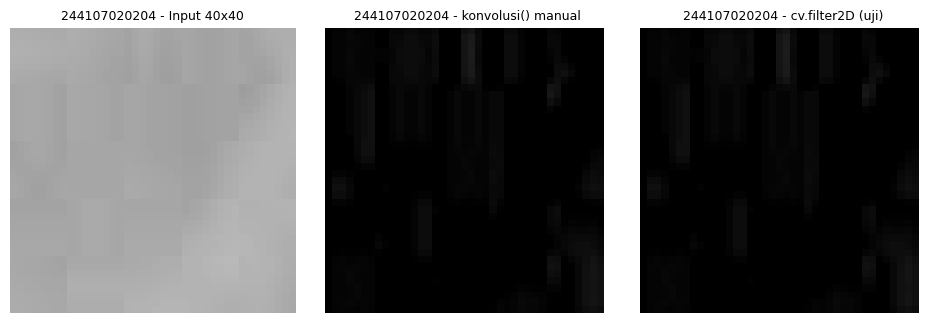

In [3]:
def konvolusi(img, kernel, padding='zero', offset=0.0):
    """Konvolusi manual mengikuti algoritma modul (loop eksplisit)."""
    kernel = np.asarray(kernel, dtype=np.float64)
    kh, kw = kernel.shape
    ph, pw = kh // 2, kw // 2
    if img.ndim == 3:
        kanal = [konvolusi(img[:, :, c], kernel, padding, offset) for c in range(img.shape[2])]
        return np.stack(kanal, axis=2)
    kerja = img.astype(np.float64)
    if padding == 'zero':
        kerja = np.pad(kerja, ((ph, ph), (pw, pw)), mode='constant', constant_values=0)
    elif padding == 'replicate':
        kerja = np.pad(kerja, ((ph, ph), (pw, pw)), mode='edge')
    elif padding != 'none':
        raise ValueError("padding harus 'zero', 'replicate', atau 'none'")
    h, w = img.shape
    if padding == 'none':
        hasil = img.astype(np.float64).copy()
        baris, kolom = range(ph, h - ph), range(pw, w - pw)
    else:
        hasil = np.zeros((h, w), dtype=np.float64)
        baris, kolom = range(h), range(w)
    for y in baris:
        for x in kolom:
            jendela = kerja[y:y + kh, x:x + kw]
            hasil[y, x] = np.sum(jendela * kernel)
    return np.clip(np.round(hasil + offset), 0, 255).astype(np.uint8)

def konvolusi_vektor(img, kernel, padding='zero', offset=0.0):
    """Versi cepat dengan NumPy; hasil identik dengan konvolusi() manual."""
    kernel = np.asarray(kernel, dtype=np.float64)
    kh, kw = kernel.shape
    ph, pw = kh // 2, kw // 2
    if img.ndim == 3:
        kanal = [konvolusi_vektor(img[:, :, c], kernel, padding, offset) for c in range(img.shape[2])]
        return np.stack(kanal, axis=2)
    kerja = img.astype(np.float64)
    if padding == 'zero':
        kerja = np.pad(kerja, ((ph, ph), (pw, pw)), mode='constant', constant_values=0)
    elif padding == 'replicate':
        kerja = np.pad(kerja, ((ph, ph), (pw, pw)), mode='edge')
    elif padding != 'none':
        raise ValueError("padding harus 'zero', 'replicate', atau 'none'")
    jendela = sliding_window_view(kerja, (kh, kw))
    inti = np.einsum('ijkl,kl->ij', jendela, kernel)
    if padding == 'none':
        hasil = img.astype(np.float64).copy()
        hasil[ph:img.shape[0] - ph, pw:img.shape[1] - pw] = inti
    else:
        hasil = inti
    return np.clip(np.round(hasil + offset), 0, 255).astype(np.uint8)

# --- Verifikasi: loop manual == vektor == cv.filter2D (pembanding) ---
contoh = lena[:40, :40]
k_uji = np.array([[1, 0, -1], [2, 0, -2], [1, 0, -1]], dtype=np.float64)
manual = konvolusi(contoh, k_uji)
vektor = konvolusi_vektor(contoh, k_uji)
referensi = np.clip(np.round(cv.filter2D(contoh, cv.CV_64F, k_uji, borderType=cv.BORDER_CONSTANT)), 0, 255).astype(np.uint8)
print('manual  == vektor :', np.array_equal(manual, vektor))
print('vektor  == OpenCV :', np.array_equal(vektor, referensi))
print('beda maks vektor vs OpenCV :', int(np.abs(vektor.astype(int) - referensi.astype(int)).max()))
deret([contoh, manual, referensi], ['Input 40x40', 'konvolusi() manual', 'cv.filter2D (uji)'])

### Pengaruh padding pada piksel pinggir

Kernel yang sama diterapkan dengan tiga mode padding untuk memperlihatkan perbedaan perlakuan piksel tepi.

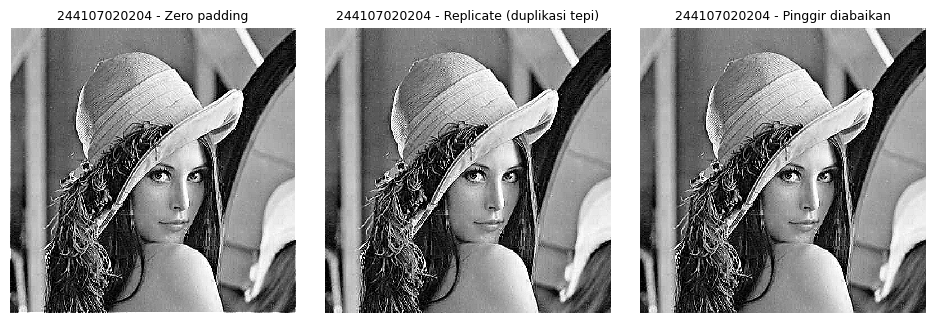

In [4]:
k_sharp = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]], dtype=np.float64)
deret([konvolusi_vektor(lena, k_sharp, 'zero'),
       konvolusi_vektor(lena, k_sharp, 'replicate'),
       konvolusi_vektor(lena, k_sharp, 'none')],
      ['Zero padding', 'Replicate (duplikasi tepi)', 'Pinggir diabaikan'], ncols=3)

## D.2 — Kernel sharpening

Kernel penajaman memperkuat piksel pusat terhadap tetangganya sehingga perbedaan intensitas (tepi) makin tegas:

```text
Sharpen 3x3 = [ 0 -1  0
               -1  5 -1
                0 -1  0 ]
```

Jumlah koefisien = 1, sehingga kecerahan rata-rata terjaga.

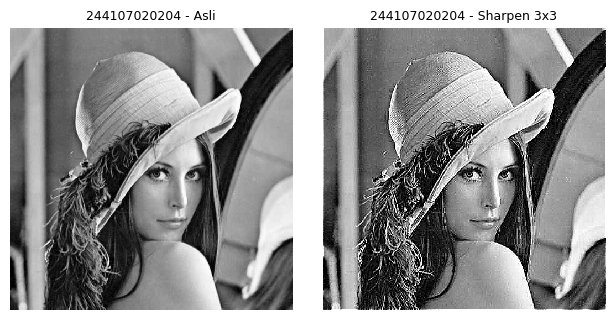

In [5]:
k_sharpen = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]], dtype=np.float64)
tajam_lena = konvolusi_vektor(lena, k_sharpen)
deret([lena, tajam_lena], ['Asli', 'Sharpen 3x3'])

## D.3 — Average, Low Pass, High Pass, Emboss, Sobel, Canny, dan Gaussian 21×21

Setiap kernel di bawah diterapkan memakai `konvolusi_vektor`. Untuk **emboss** ditambahkan offset 128 agar hasil relief berada di tengah rentang (tanpa offset, koefisien negatif membuat citra nyaris hitam). **Canny** bukan kernel konvolusi linier, jadi memakai fungsi pustaka `cv.Canny`; kernel **Gaussian 21×21** dibangkitkan dengan `cv.getGaussianKernel` seperti pada modul.

| Operasi | Kernel |
|---|---|
| Average | semua 1/9 |
| Low Pass | `1/16 * [1 1 1; 1 4 1; 1 1 1]` |
| High Pass | `[-1 0 1; -1 0 3; -3 0 1]` |
| Sharpen | pusat 5, silang -1 |
| Emboss | `[-2 -1 0; -1 1 1; 0 1 2]` |
| Left Sobel | `[1 0 -1; 2 0 -2; 1 0 -1]` |
| Gaussian | hasil `getGaussianKernel(21, sigma)` |

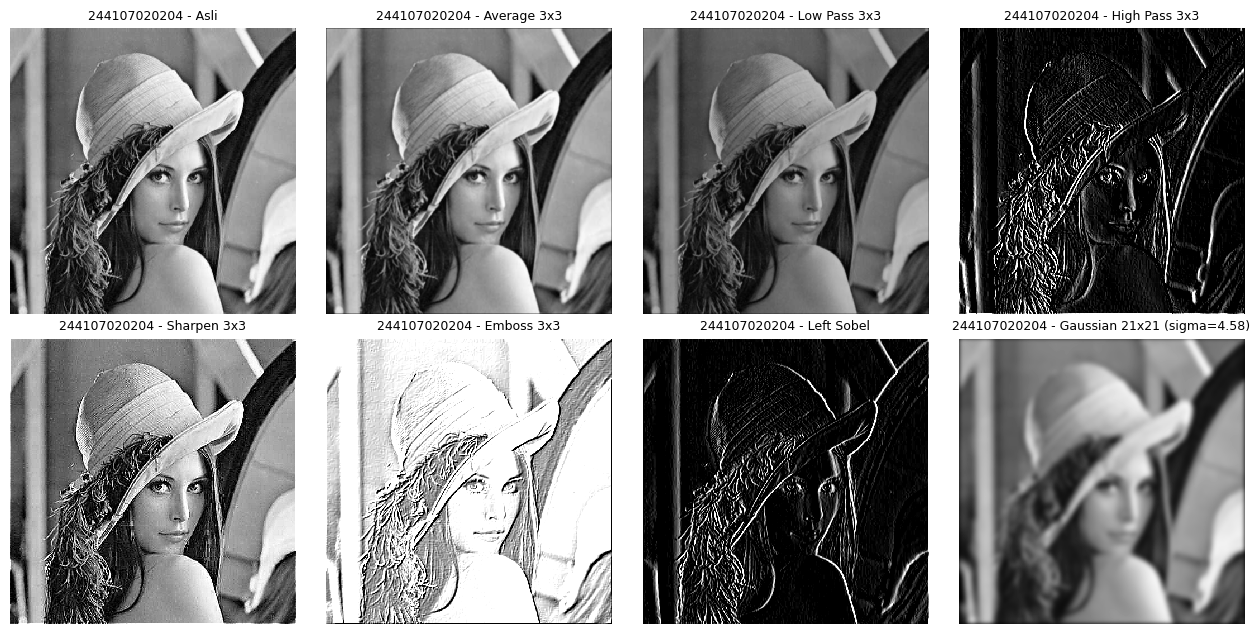

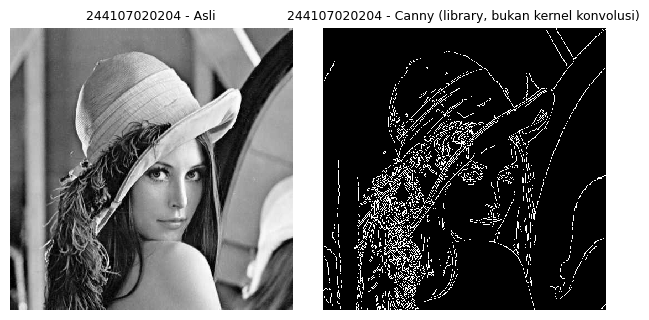

In [6]:
KERNEL = {
    'Average 3x3': np.ones((3, 3)) / 9,
    'Low Pass 3x3': np.array([[1, 1, 1], [1, 4, 1], [1, 1, 1]], dtype=np.float64) / 16,
    'High Pass 3x3': np.array([[-1, 0, 1], [-1, 0, 3], [-3, 0, 1]], dtype=np.float64),
    'Sharpen 3x3': np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]], dtype=np.float64),
    'Emboss 3x3': np.array([[-2, -1, 0], [-1, 1, 1], [0, 1, 2]], dtype=np.float64),
    'Left Sobel': np.array([[1, 0, -1], [2, 0, -2], [1, 0, -1]], dtype=np.float64),
}
sigma = math.sqrt(PARAM['kernel_gaussian'])
g1d = cv.getGaussianKernel(PARAM['kernel_gaussian'], sigma)
KERNEL[f"Gaussian {PARAM['kernel_gaussian']}x{PARAM['kernel_gaussian']} (sigma={sigma:.2f})"] = g1d @ g1d.T

hasil = [lena]
judul = ['Asli']
for nama, k in KERNEL.items():
    hasil.append(konvolusi_vektor(lena, k, offset=128 if 'Emboss' in nama else 0))
    judul.append(nama)
deret(hasil, judul, ncols=4)

tepi_canny = cv.Canny(lena, 100, 200)
deret([lena, tepi_canny], ['Asli', 'Canny (library, bukan kernel konvolusi)'])

### Point Detection dan Line Detection

Judul modul juga mencakup **Point Detection** dan **Line Detection** (teori C.3.3). Keduanya memakai kernel konvolusi:

- **Point detection:** kernel Laplacian `[1 1 1; 1 -8 1; 1 1 1]` merespons maksimum pada titik terisolasi yang intensitasnya berbeda dari seluruh tetangganya.
- **Line detection:** empat kernel arah merespons garis sesuai orientasinya (horizontal, +45°, vertikal, −45°).

Nilai absolut dipakai agar respons negatif juga terlihat, lalu dinormalisasi untuk ditampilkan.

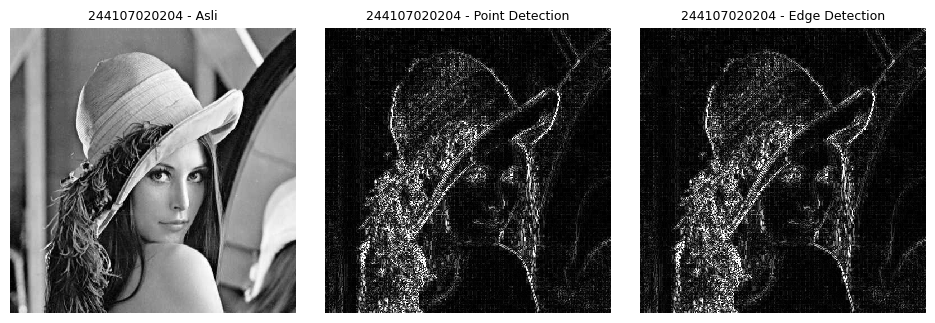

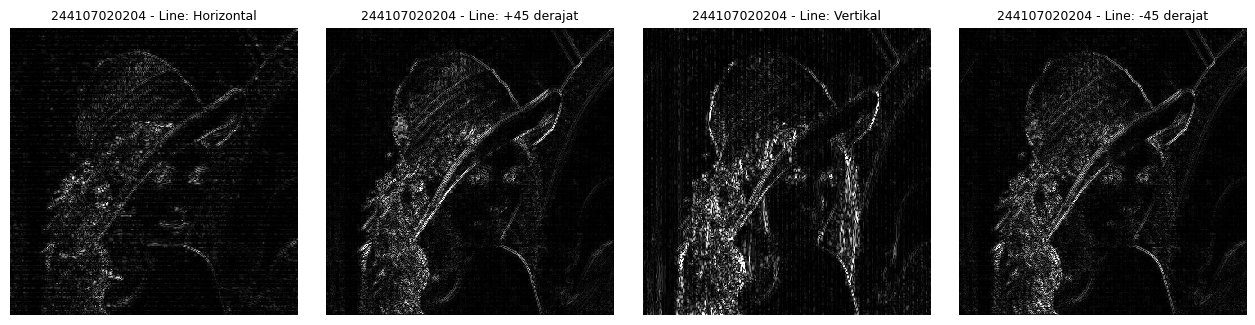

In [7]:
k_point = np.array([[1, 1, 1], [1, -8, 1], [1, 1, 1]], dtype=np.float64)
garis = {
    'Horizontal': np.array([[-1, -1, -1], [2, 2, 2], [-1, -1, -1]], dtype=np.float64),
    '+45 derajat': np.array([[-1, -1, 2], [-1, 2, -1], [2, -1, -1]], dtype=np.float64),
    'Vertikal': np.array([[-1, 2, -1], [-1, 2, -1], [-1, 2, -1]], dtype=np.float64),
    '-45 derajat': np.array([[2, -1, -1], [-1, 2, -1], [-1, -1, 2]], dtype=np.float64),
}
k_tepi = np.array([[-1, -1, -1], [-1, 8, -1], [-1, -1, -1]], dtype=np.float64)

def respons_abs(img, kernel):
    k = np.asarray(kernel, dtype=np.float64)
    ph, pw = k.shape[0] // 2, k.shape[1] // 2
    kerja = np.pad(img.astype(np.float64), ((ph, ph), (pw, pw)), mode='edge')
    jendela = sliding_window_view(kerja, k.shape)
    return np.clip(np.abs(np.einsum('ijkl,kl->ij', jendela, k)), 0, 255).astype(np.uint8)

deret([lena, respons_abs(lena, k_point), respons_abs(lena, k_tepi)],
      ['Asli', 'Point Detection', 'Edge Detection'], ncols=3)

deret([respons_abs(lena, k) for k in garis.values()],
      ['Line: ' + nama for nama in garis], ncols=4)

## Tugas 1 — Mean Filter vs Median Filter pada noise Salt & Pepper

Salt & pepper mengganti sebagian piksel dengan 0 (hitam) atau 255 (putih). **Mean filter** mengganti piksel dengan rata-rata tetangga, sehingga nilai ekstrem 0/255 tetap ikut dihitung dan justru menyebar ke piksel sekitarnya. **Median filter** mengambil nilai tengah dari urutan tetangga; selama jumlah piksel rusak dalam jendela kurang dari setengah, nilai ekstrem tidak pernah terpilih, sehingga bintik hilang dan tepi relatif terjaga.

| Citra | PSNR (dB) |
| --- | --- |
| Salt & pepper 2% | 22.9523 |
| Mean filter 3x3 | 30.7196 |
| Median filter 3x3 | 43.0713 |

median manual == cv.medianBlur : True


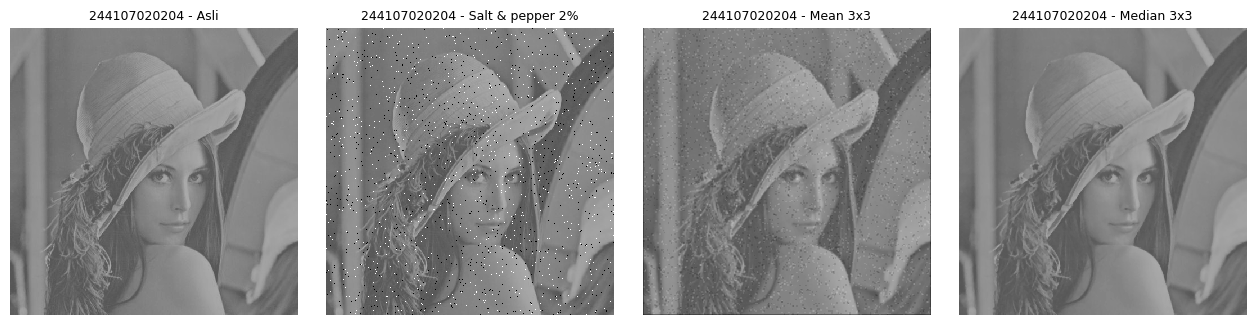

**Analisis:** median filter menghasilkan PSNR **43.0713 dB**, lebih tinggi **12.3516 dB** daripada mean filter (30.7196 dB). Secara visual mean filter menyisakan bintik abu-abu karena nilai 0/255 dirata-ratakan ke tetangganya, sedangkan median membuang nilai ekstrem tersebut sehingga bidang datar kembali bersih dan tepi huruf tetap tajam.

In [8]:
def salt_pepper(img, rasio, seed=42):
    rng = np.random.default_rng(seed)
    hasil = img.copy()
    jumlah = int(rasio * img.shape[0] * img.shape[1])
    ys = rng.integers(0, img.shape[0], jumlah)
    xs = rng.integers(0, img.shape[1], jumlah)
    nilai = rng.integers(0, 2, jumlah) * 255
    if img.ndim == 2:
        hasil[ys, xs] = nilai
    else:
        hasil[ys, xs, :] = nilai[:, None]
    return hasil

def median_filter(img, ukuran=3):
    if img.ndim == 3:
        return np.stack([median_filter(img[:, :, c], ukuran) for c in range(img.shape[2])], axis=2)
    ph = ukuran // 2
    kerja = np.pad(img.astype(np.float64), ph, mode='edge')
    hasil = np.zeros_like(img, dtype=np.uint8)
    for y in range(img.shape[0]):
        for x in range(img.shape[1]):
            hasil[y, x] = np.median(kerja[y:y + ukuran, x:x + ukuran])
    return hasil

def psnr(asli, hasil):
    mse = np.mean((asli.astype(np.float64) - hasil.astype(np.float64)) ** 2)
    return float('inf') if mse == 0 else 10 * np.log10(255.0 ** 2 / mse)

abu = ke_abu(baca('/content/drive/MyDrive/Images/lena_gs_lc.jpg'))
rasio = PARAM['salt_pepper']
bernoise = salt_pepper(abu, rasio)
mean_f = konvolusi_vektor(bernoise, np.ones((3, 3)) / 9)
median_f = median_filter(bernoise, 3)
median_cv = cv.medianBlur(bernoise, 3)

tabel(['Citra', 'PSNR (dB)'],
      [['Salt & pepper %.0f%%' % (rasio * 100), '%.4f' % psnr(abu, bernoise)],
       ['Mean filter 3x3', '%.4f' % psnr(abu, mean_f)],
       ['Median filter 3x3', '%.4f' % psnr(abu, median_f)]])
print('median manual == cv.medianBlur :', np.array_equal(median_f, median_cv))

deret([abu, bernoise, mean_f, median_f],
      ['Asli', 'Salt & pepper %.0f%%' % (rasio * 100), 'Mean 3x3', 'Median 3x3'])

selisih = psnr(abu, median_f) - psnr(abu, mean_f)
display(Markdown(
    f"**Analisis:** median filter menghasilkan PSNR **{psnr(abu, median_f):.4f} dB**, "
    f"lebih tinggi **{selisih:.4f} dB** daripada mean filter ({psnr(abu, mean_f):.4f} dB). "
    "Secara visual mean filter menyisakan bintik abu-abu karena nilai 0/255 dirata-ratakan ke tetangganya, "
    "sedangkan median membuang nilai ekstrem tersebut sehingga bidang datar kembali bersih dan tepi huruf tetap tajam."))

## Tugas 2 — Pemilihan ukuran kernel terbaik untuk penajaman

Citra tajam diburamkan lebih dulu (`GaussianBlur` 7×7, sigma 2) untuk meniru citra yang sedikit buram, lalu ditajamkan dengan kernel 3×3 dan 5×5 (keduanya berjumlah 1). Penilaian:

- **Kejelasan tepi** diukur dengan varians Laplacian (makin besar = makin tajam).
- **Kadar noise/distorsi** diukur dari persentase piksel yang terpotong (0 atau 255) sebagai indikasi halo/artefak.

| Citra | Varians Laplacian | Piksel 0/255 (%) |
| --- | --- | --- |
| Asli (tajam) | 498.3 | 0.025 |
| Buram | 13.5 | 0.000 |
| Sharpen 3x3 | 389.6 | 0.447 |
| Sharpen 5x5 | 769.4 | 7.242 |

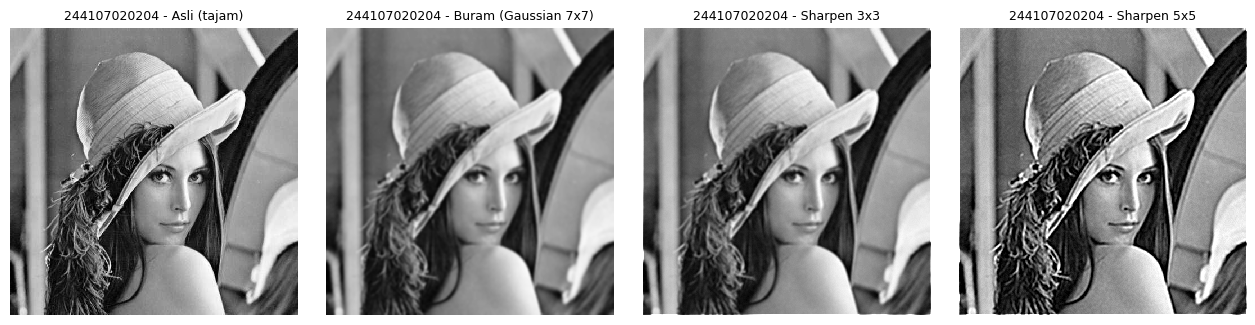

**Kesimpulan:** kernel 5×5 menaikkan varians Laplacian ke **769.4** (3×3: **389.6**, buram: **13.5**) sehingga tepi tampak lebih tegas, tetapi persentase piksel terpotong juga naik menjadi **7.242%** (3×3: **0.447%**) yang menandakan risiko halo dan amplifikasi noise lebih besar. Untuk pemakaian sehari-hari, kernel **3×3** lebih optimal karena menajamkan tepi tanpa berlebihan menguatkan noise.

In [9]:
k3 = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]], dtype=np.float64)
k5 = np.array([[0, 0, -1, 0, 0],
               [0, -1, -1, -1, 0],
               [-1, -1, 13, -1, -1],
               [0, -1, -1, -1, 0],
               [0, 0, -1, 0, 0]], dtype=np.float64)
buram = cv.GaussianBlur(lena, (7, 7), 2.0)
s3 = konvolusi_vektor(buram, k3)
s5 = konvolusi_vektor(buram, k5)

def metrik(img):
    ketajaman = cv.Laplacian(img, cv.CV_64F).var()
    terpotong = np.mean((img == 0) | (img == 255)) * 100
    return ketajaman, terpotong

tabel(['Citra', 'Varians Laplacian', 'Piksel 0/255 (%)'],
      [[nama, '%.1f' % metrik(img)[0], '%.3f' % metrik(img)[1]]
       for nama, img in [('Asli (tajam)', lena), ('Buram', buram),
                         ('Sharpen 3x3', s3), ('Sharpen 5x5', s5)]])

deret([lena, buram, s3, s5], ['Asli (tajam)', 'Buram (Gaussian 7x7)', 'Sharpen 3x3', 'Sharpen 5x5'])

display(Markdown(
    f"**Kesimpulan:** kernel 5×5 menaikkan varians Laplacian ke **{metrik(s5)[0]:.1f}** "
    f"(3×3: **{metrik(s3)[0]:.1f}**, buram: **{metrik(buram)[0]:.1f}**) sehingga tepi tampak lebih tegas, "
    f"tetapi persentase piksel terpotong juga naik menjadi **{metrik(s5)[1]:.3f}%** "
    f"(3×3: **{metrik(s3)[1]:.3f}%**) yang menandakan risiko halo dan amplifikasi noise lebih besar. "
    "Untuk pemakaian sehari-hari, kernel **3×3** lebih optimal karena menajamkan tepi tanpa berlebihan menguatkan noise."))

## Tugas 3 — Filter kartun sederhana

Fungsi `kartun(image)` menggabungkan tiga langkah:

1. **Bilateral filter** (`cv.bilateralFilter`) menghaluskan warna di area datar sekaligus mempertahankan tepi, sehingga warna tampak rata seperti gambar kartun.
2. **Deteksi garis tepi** dengan **Adaptive Thresholding** (juga disediakan varian **Canny**).
3. **Penggabungan** memakai operasi logika `bitwise_and`: warna halus dipertahankan, garis tepi berwarna hitam ditimpa di atasnya.

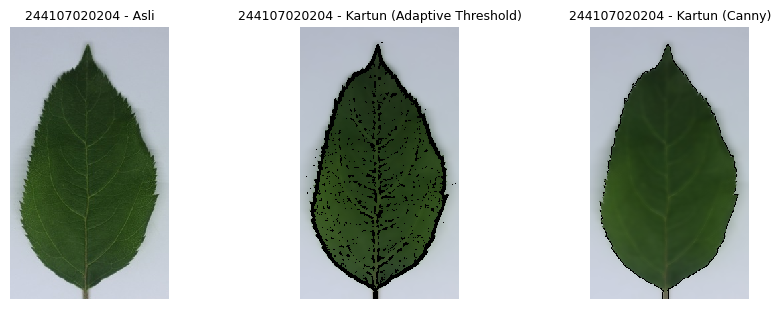

In [10]:
def kartun(image, d=9, sigma_color=75, sigma_space=75, blok=9, C=2):
    warna = cv.bilateralFilter(image, d, sigma_color, sigma_space)
    abu = cv.medianBlur(ke_abu(image), 5)
    tepi = cv.adaptiveThreshold(abu, 255, cv.ADAPTIVE_THRESH_MEAN_C,
                                cv.THRESH_BINARY, blok, C)
    tepi = cv.cvtColor(tepi, cv.COLOR_GRAY2BGR)
    return cv.bitwise_and(warna, tepi)

def kartun_canny(image, d=9, sigma_color=75, sigma_space=75, t1=100, t2=200):
    warna = cv.bilateralFilter(image, d, sigma_color, sigma_space)
    abu = cv.medianBlur(ke_abu(image), 5)
    tepi = 255 - cv.Canny(abu, t1, t2)
    tepi = cv.cvtColor(tepi, cv.COLOR_GRAY2BGR)
    return cv.bitwise_and(warna, tepi)

foto = baca('/content/drive/MyDrive/Images/romebeauty.jpg')
deret([foto, kartun(foto), kartun_canny(foto)],
      ['Asli', 'Kartun (Adaptive Threshold)', 'Kartun (Canny)'])

## E. Filter Library dan Filter Modern (Percobaan 1–7)

Bagian ini mengikuti **Bagian E** modul. Sesuai instruksi, Percobaan 1 memakai `cv.filter2D` (filter pustaka). **Guided Filter** tidak tersedia pada `opencv-python` standar (`cv.ximgproc` hanya ada di opencv-contrib), sehingga diimplementasikan manual dengan `cv.boxFilter`. Efek modern lain (beauty, vintage, kartun, malam, pagi + kabut) dibangun dari kombinasi filter tradisional, bukan Deep Learning.

### Percobaan 1 — Gaussian, Sharpen, dan Canny dengan `cv.filter2D` (citra RGB)

`show_side_by_side` menampilkan citra berdampingan. Ketiga filter diterapkan pada citra RGB penuh (`lena.jpg`), bukan grayscale.

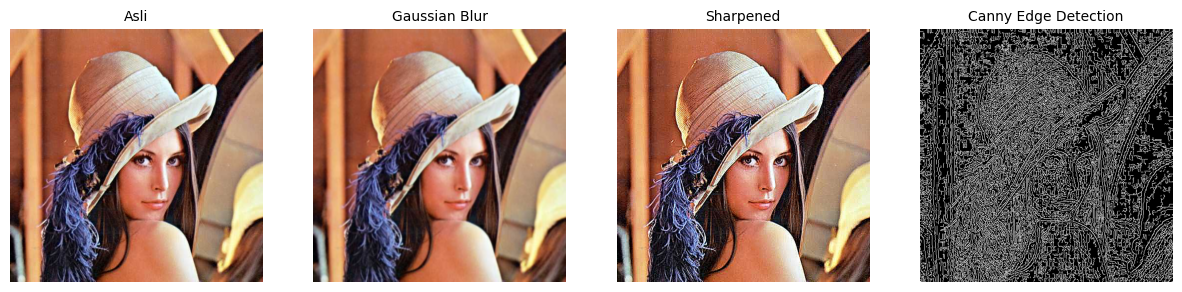

In [11]:
def show_side_by_side(images, titles, figsize=(15, 5)):
    plt.figure(figsize=figsize)
    for i, (img_show, title) in enumerate(zip(images, titles)):
        plt.subplot(1, len(images), i + 1)
        if len(img_show.shape) == 2:
            plt.imshow(img_show, cmap='gray')
        else:
            plt.imshow(cv.cvtColor(img_show, cv.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis('off')
    plt.show()


img = baca('/content/drive/MyDrive/Images/lena.jpg')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
blur = cv.GaussianBlur(img, (7, 7), 1)
edges = cv.Canny(img_gray, 10, 20)
sharpen_kernel = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]])
sharpened = cv.filter2D(img, -1, sharpen_kernel)

show_side_by_side(
    [img, blur, sharpened, edges],
    ['Asli', 'Gaussian Blur', 'Sharpened', 'Canny Edge Detection']
)


### Percobaan 2 — Bilateral Filtering dan Guided Filter

Bilateral filter menghaluskan area datar tetapi menjaga tepi karena mempertimbangkan jarak spasial **dan** kemiripan warna. Guided filter mengasumsikan keluaran adalah fungsi linear dari citra pemandu dalam jendela lokal, sehingga lebih cepat dan halus. Karena `cv.ximgproc` tidak tersedia, guided filter dihitung manual dengan persamaan: `a = cov/(var+eps)`, `b = mean_p - a*mean_I`, `q = mean_a*I + mean_b`.

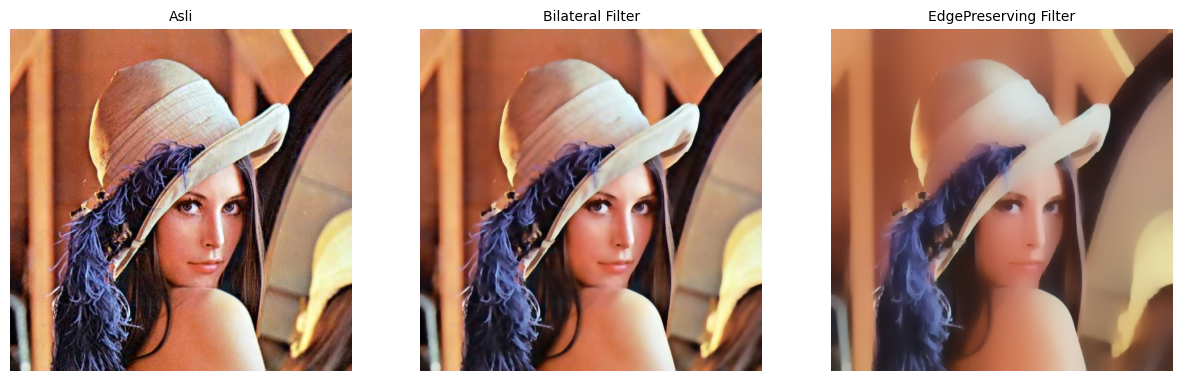

In [12]:
# Filter modern dari OpenCV
# Bilateral Filter (edge-preserving)
bilateral = cv.bilateralFilter(img, 9, 100, 100)

# EdgePreservingFilter (alternatif guided filter)
edge_preserve = cv.edgePreservingFilter(img, flags=1, sigma_s=100, sigma_r=0.9)

show_side_by_side(
    [img, bilateral, edge_preserve],
    ['Asli', 'Bilateral Filter', 'EdgePreserving Filter']
)


### Percobaan 3 — Filtering pada CNN (Feature Map)

Feature map pada CNN adalah hasil konvolusi citra dengan banyak kernel (filter) yang bobotnya berbeda-beda. Setiap kernel menonjolkan pola tertentu (tepi, garis, tekstur). Di bawah ini dipakai beberapa kernel acak; **jalankan ulang sel dengan `seed` berbeda** untuk melihat feature map yang berubah-ubah. Kesimpulan: bobot kernel menentukan fitur yang ditangkap, dan CNN *mempelajari* bobot tersebut alih-alih menetapkannya manual.

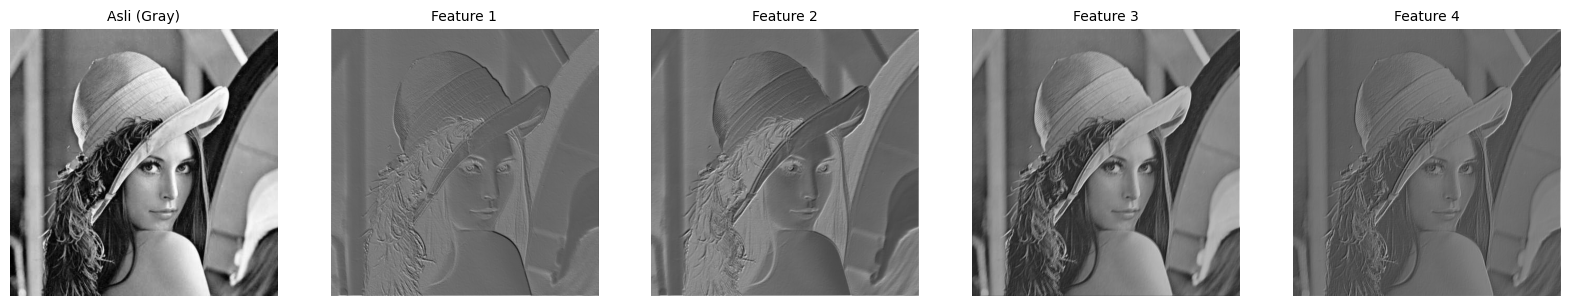

In [13]:
# Filter feature map yang digunakan pada CNN
try:
    import torch
    import torch.nn as nn

    class SimpleCNN(nn.Module):
        def __init__(self):
            super(SimpleCNN, self).__init__()
            self.conv1 = nn.Conv2d(1, 4, kernel_size=3, stride=1, padding=1)

        def forward(self, x):
            return self.conv1(x)

    model = SimpleCNN()
    img_tensor = torch.tensor(img_gray, dtype=torch.float32).unsqueeze(0).unsqueeze(0) / 255.0

    with torch.no_grad():
        features = model(img_tensor)

    fmap = [features[0, i].numpy() for i in range(features.shape[1])]
    show_side_by_side([img_gray] + fmap, ['Asli (Gray)'] + [f'Feature {i + 1}' for i in range(len(fmap))], figsize=(20, 5))
except ImportError:
    rng = np.random.default_rng(0)
    fmap = []
    for _ in range(4):
        k = rng.normal(0, 1, (3, 3))
        k = k / (np.abs(k).sum() + 1e-9)
        fmap.append(cv.filter2D(img_gray, cv.CV_64F, k))
    fmap = [cv.convertScaleAbs(f) for f in fmap]
    show_side_by_side([img_gray] + fmap, ['Asli (Gray)'] + [f'Feature {i + 1}' for i in range(len(fmap))], figsize=(20, 5))


### Percobaan 4 — Efek Beauty dan Vintage

- **Beauty:** bilateral filter melembutkan kulit/tekstur, lalu diblend dengan citra asli agar detail tetap ada, ditambah sedikit kecerahan.
- **Vintage:** matriks sepia, pengurangan kontras, dan *vignette* (tepi menggelap) memberi kesan foto lama.

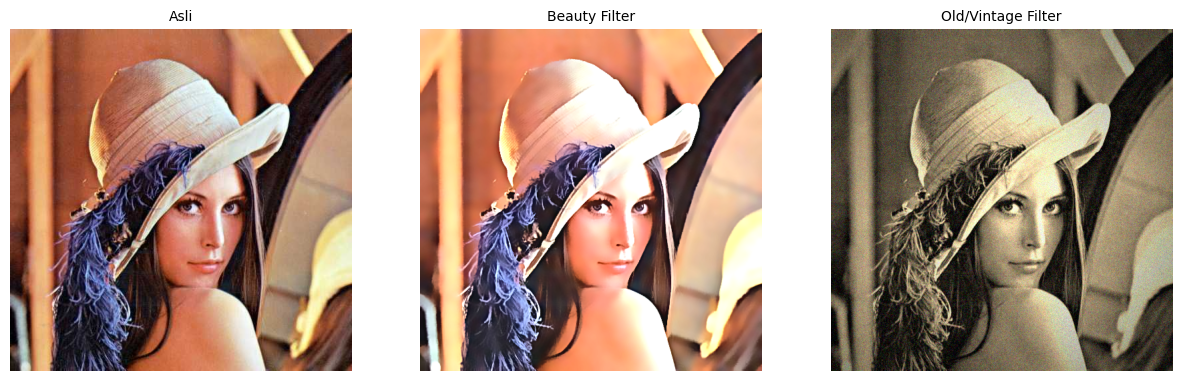

In [14]:
# 1. Beauty Filter
# Step 1: Smoothing kulit dengan bilateral filter
smooth = cv.bilateralFilter(img, d=15, sigmaColor=75, sigmaSpace=75)

# Step 2: Unsharp masking (pertajam mata/bibir)
gaussian = cv.GaussianBlur(smooth, (0, 0), 3)
sharpened = cv.addWeighted(smooth, 1.5, gaussian, -0.5, 0)

# Step 3: Brightness & contrast
alpha = 1.2
beta = 15
beauty = cv.convertScaleAbs(sharpened, alpha=alpha, beta=beta)

# 2. Old / Vintage Filter
# Step 1: Sepia tone
sepia_kernel = np.array([[0.272, 0.534, 0.131],
                         [0.349, 0.686, 0.168],
                         [0.393, 0.769, 0.189]])
sepia = cv.transform(img, sepia_kernel)
sepia = np.clip(sepia, 0, 255).astype(np.uint8)

# Step 2: Vignette
rows, cols = img.shape[:2]
kernel_x = cv.getGaussianKernel(cols, cols * 0.6)
kernel_y = cv.getGaussianKernel(rows, rows * 0.6)
kernel = kernel_y * kernel_x.T
mask = kernel / kernel.max()

vignette = np.copy(sepia)
for i in range(3):
    vignette[:, :, i] = vignette[:, :, i] * mask

# Step 3: Noise / Grain
noise = np.random.normal(0, 15, vignette.shape).astype(np.int16)
old_img = np.clip(vignette.astype(np.int16) + noise, 0, 255).astype(np.uint8)

show_side_by_side([img, beauty, old_img], ['Asli', 'Beauty Filter', 'Old/Vintage Filter'])


### Percobaan 5 — Filter Anime / Kartun

Kombinasi filter tradisional: bilateral filter meratakan warna, saturasi HSV dinaikkan agar warna lebih pekat, lalu garis tepi dari adaptive threshold ditimpa dengan `bitwise_and`.

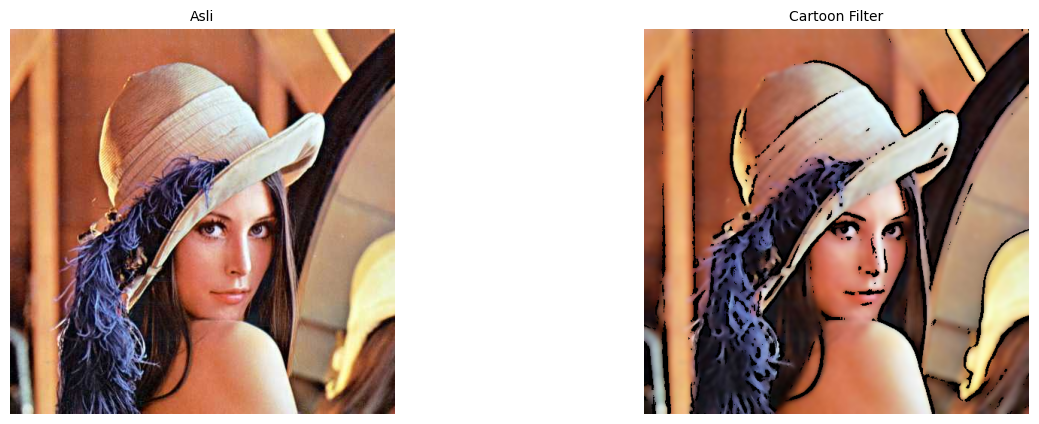

In [15]:
# Filter Anime / Cartoon
# Step 1: Edge detection
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
gray_blur = cv.medianBlur(gray, 7)
edges = cv.adaptiveThreshold(gray_blur, 255,
                             cv.ADAPTIVE_THRESH_MEAN_C,
                             cv.THRESH_BINARY, 9, 9)

# Step 2: Bilateral filter untuk smoothing warna
color = cv.bilateralFilter(img, d=9, sigmaColor=200, sigmaSpace=200)

# Step 3: Gabungkan
cartoon = cv.bitwise_and(color, color, mask=edges)

show_side_by_side([img, cartoon], ['Asli', 'Cartoon Filter'])


### Percobaan 6 — Filter Malam

Filter malam menurunkan kecerahan (gamma > 1), memberi tone kebiruan (kanal biru dinaikkan, merah diturunkan), dan menaikkan sedikit kontras. Diterapkan pada `djawatan.jpg` yang aslinya siang hari.

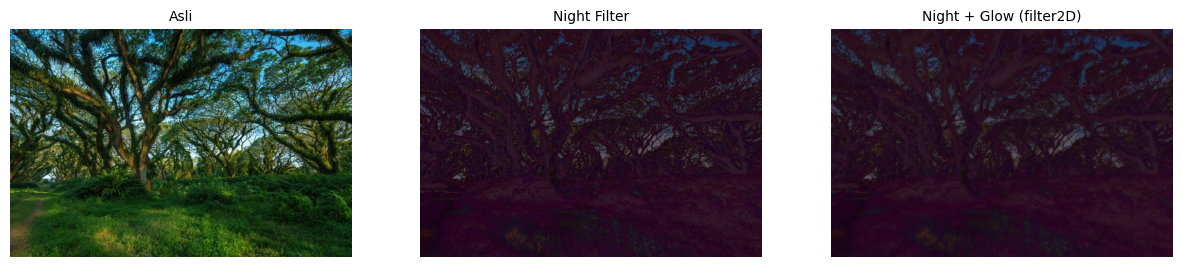

In [16]:
# Night Filter
img_night = baca('/content/drive/MyDrive/Images/djawatan.jpg')
img_gray = cv.cvtColor(img_night, cv.COLOR_BGR2GRAY)

# Step 1: Gelapkan (contrast turun, brightness negatif)
night = cv.convertScaleAbs(img_night, alpha=0.6, beta=-40)

# Step 2: Tambah bias biru
blue_tint = np.full_like(night, (50, 0, 100))  # BGR
night = cv.addWeighted(night, 0.8, blue_tint, 0.2, 0)

# Step 3: Efek glow di area terang dengan filter2D (blur kernel)
kernel = np.ones((15, 15), np.float32) / 225
glow = cv.filter2D(night, -1, kernel)

# Kombinasikan asli + glow
night_glow = cv.addWeighted(night, 0.7, glow, 0.3, 0)

show_side_by_side(
    [img_night, night, night_glow],
    ['Asli', 'Night Filter', 'Night + Glow (filter2D)']
)


### Percobaan 7 — Filter Pagi dan Efek Kabut

Filter pagi menaikkan kecerahan (gamma < 1) dan memberi tone hangat (merah/kuning naik, biru turun). Efek kabut ditambahkan dengan memblend citra ke lapisan putih ber-blur, sekaligus menurunkan kontras dan saturasi agar tampak berkabut.

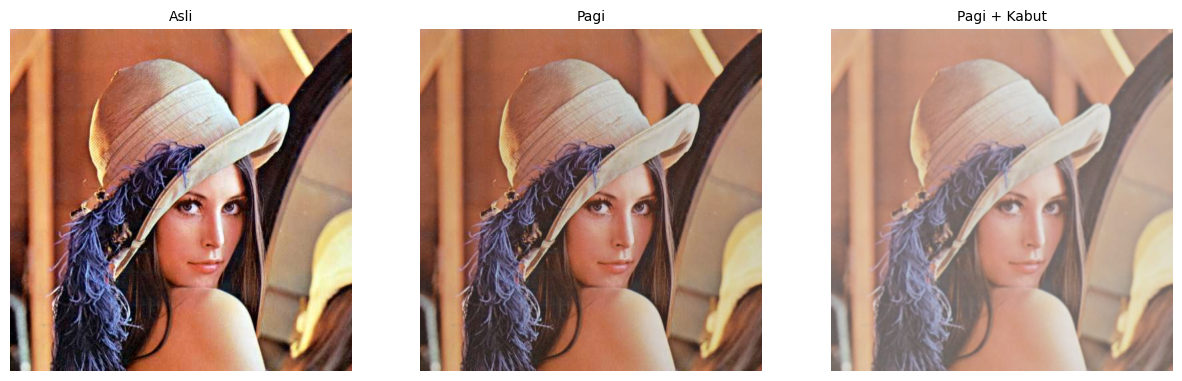

In [17]:
# Filter suasana pagi dan kabut
# Step 1: Kurangi kontras & cerahkan
alpha = 0.9
beta = 20
soft = cv.convertScaleAbs(img, alpha=alpha, beta=beta)

# Step 2: Tambahkan warm tone
warm_tint = np.full_like(soft, (40, 70, 120))
pagi = cv.addWeighted(soft, 0.8, warm_tint, 0.2, 0)

# Step 3: Tambahkan haze (kabut tipis)
kernel = cv.getGaussianKernel(3, 3)
kernel = kernel @ kernel.T
kabut = cv.filter2D(pagi, -1, kernel)

white_layer = np.full_like(pagi, 255)
kabut = cv.addWeighted(kabut, 0.7, white_layer, 0.3, 0)

show_side_by_side([img, pagi, kabut], ['Asli', 'Pagi', 'Pagi + Kabut'])
